<a href="https://colab.research.google.com/github/di-claro-batera/faculdade_data_science/blob/main/Classifica%C3%A7%C3%A3o_de_Imagens.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Classificação de Imagens

* Importando os pacotes necessários
* Carregando as imagens de faces
* Construindo os conjuntos de treinamento e teste
*Treinando e ajustando parâmetros do SVM
* Avaliando os resultados

# Importando os Pacotes

In [5]:
!pip install scikit-learn
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

# usar seaborn plotting defaults
import seaborn as sns; sns.set()

# Classificação de imagens (Reconhecimento Facial)

O problema de reconhecimento facial pode ser visto como um problema de classificação de imagens quando (i) a imagem apresenta uma face (rosto) e (ii) há um rótulo (classe) associado a ela.

Usaremos o conjunto de dados Labeled Faces in the Wild, composto por milhares de imagens faciais de várias figuras públicas. Esses dados estão disponíveis no scikit-learn.

# Carregando as imagens de faces

In [7]:
from sklearn.datasets import fetch_lfw_people
faces = fetch_lfw_people(min_faces_per_person=60)
print("Número de faces (classes)= ", faces.target_names.size)
print("Faces = ", faces.target_names)
print("Dimensões= ", faces.images.shape)

Número de faces (classes)=  8
Faces =  ['Ariel Sharon' 'Colin Powell' 'Donald Rumsfeld' 'George W Bush'
 'Gerhard Schroeder' 'Hugo Chavez' 'Junichiro Koizumi' 'Tony Blair']
Dimensões=  (1348, 62, 47)


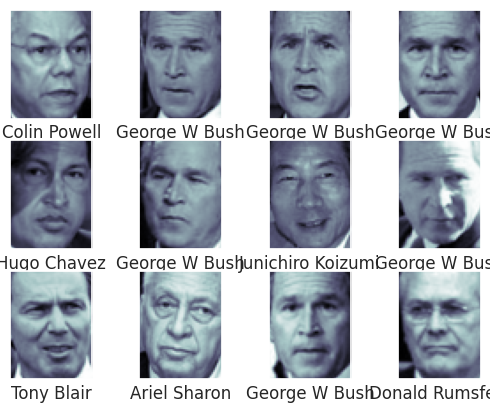

In [8]:
fig, ax = plt.subplots(3, 4)
for i, axi in enumerate(ax.flat):
    axi.imshow(faces.images[i], cmap='bone')
    axi.set(xticks=[], yticks=[],
            xlabel=faces.target_names[faces.target[i]])


# Construindo os conjuntos de treinamento e teste

Cada imagem possui [62x47], ou seja, aproximadamente 3.000 pixels.

# PCA

Poderíamos simplesmente utilizar cada pixel como um atributo (feature), mas geralmente é mais eficaz extrairmos as características mais significativas.
Utilizaremos Análise de Componentes Principais (PCA, do inglês Principal Component Analysis). Lembramos que PCA é uma das formas mais simplificadas para descrição/representação de imagens. Poderíamos utilizar descritores de histogramas de cores, como o CGH (Global Color Histogram).
Neste ponto o importante é observar que vamos trabalhar com um número bastante reduzido de atributos para cada imagem. No caso desta aplicação, vamos extrair as 150 componentes principais (n_components=150) para alimentar nosso classificador.

# SVM

As máquinas de vetores de suporte (SVM) compõem uma poderosa classe de algoritmos para aprendizado supervisionado, tanto para classificação como para regressão. Uma das principais vantagens do SVM é seu bom desempenho em problemas de alta dimensionalidade. Por essa razão, vamos utilizá-lo.

In [9]:
from sklearn.svm import SVC
from sklearn.decomposition import PCA as RandomizedPCA
from sklearn.pipeline import make_pipeline

pca = RandomizedPCA(n_components=150, whiten=True, random_state=42)
svc = SVC(kernel='rbf', class_weight='balanced')
model = make_pipeline(pca, svc)

# Para avaliar a capacidade de predição do nosso classificador SVM,
# dividiremos o conjunto de dados em treino e teste

from sklearn.model_selection import train_test_split
Xtrain, Xtest, ytrain, ytest = train_test_split(faces.data, faces.target,
                                                random_state=42)

# Treinando e ajustando parâmetros do SVM

Finalmente, podemos usar uma busca em Grid para encontrar os melhores parâmetros do classificador. Nesse caso, realizaremos uma validação cruzada (sobre o conjunto de treino) para ajustar os valores de C (que controla a rigidez da margem) e gamma (que controla o tamanho do kernel da função de base radial) e, assim, encontrar o melhor modelo:


In [10]:
from sklearn.model_selection import GridSearchCV
param_grid = {'svc__C': [1, 5, 10, 50],
              'svc__gamma': [0.0001, 0.0005, 0.001, 0.005]}
grid = GridSearchCV(model, param_grid)

%time grid.fit(Xtrain, ytrain)
print(grid.best_params_)

CPU times: user 1min 37s, sys: 145 ms, total: 1min 37s
Wall time: 57.3 s
{'svc__C': 5, 'svc__gamma': 0.001}


Os melhores valores foram encontrados no meio do grid; se estivessem nos extremos, poderíamos expandir o grid para procurar valores melhores.

Agora, com o melhor modelo encontrado, podemos prever os rótulos das imagens do conjunto de teste, as quais o modelo ainda não teve acesso:

# Avaliando os resultados

In [11]:
model = grid.best_estimator_
yfit = model.predict(Xtest)

Podemos visualizar algumas dessas imagens e os valores previstos pelo modelo:

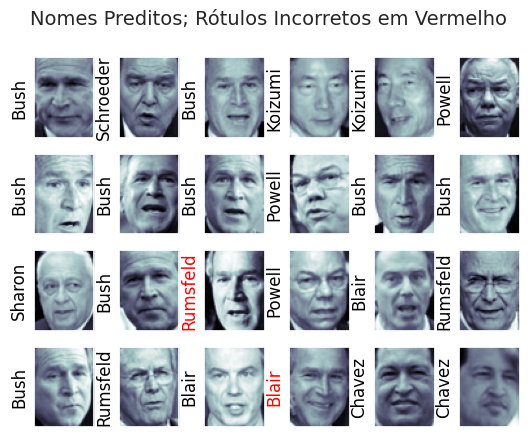

In [13]:
fig, ax = plt.subplots(4, 6)
for i, axi in enumerate(ax.flat):
  axi.imshow(Xtest[i].reshape(62, 47), cmap='bone')
  axi.set(xticks=[], yticks=[])
  axi.set_ylabel(faces.target_names[yfit[i]].split()[-1],
                 color='black' if yfit[i] == ytest[i] else 'red')
fig.suptitle('Nomes Preditos; Rótulos Incorretos em Vermelho', size=14);

Dessa pequena amostra, nosso modelo SVM classificou errado apenas duas imagens (o rosto do Bush foi rotulado como Blair e como Rumsfeld). Podemos ter uma idéia melhor do desempenho do nosso modelo se usarmos o relatório de classificação, que lista as principais estatísticas considerando cada classe:

In [14]:
from sklearn.metrics import classification_report
print(classification_report(ytest, yfit, target_names=faces.target_names))

                   precision    recall  f1-score   support

     Ariel Sharon       0.65      0.87      0.74        15
     Colin Powell       0.83      0.88      0.86        68
  Donald Rumsfeld       0.70      0.84      0.76        31
    George W Bush       0.97      0.80      0.88       126
Gerhard Schroeder       0.76      0.83      0.79        23
      Hugo Chavez       0.93      0.70      0.80        20
Junichiro Koizumi       0.86      1.00      0.92        12
       Tony Blair       0.82      0.98      0.89        42

         accuracy                           0.85       337
        macro avg       0.82      0.86      0.83       337
     weighted avg       0.86      0.85      0.85       337



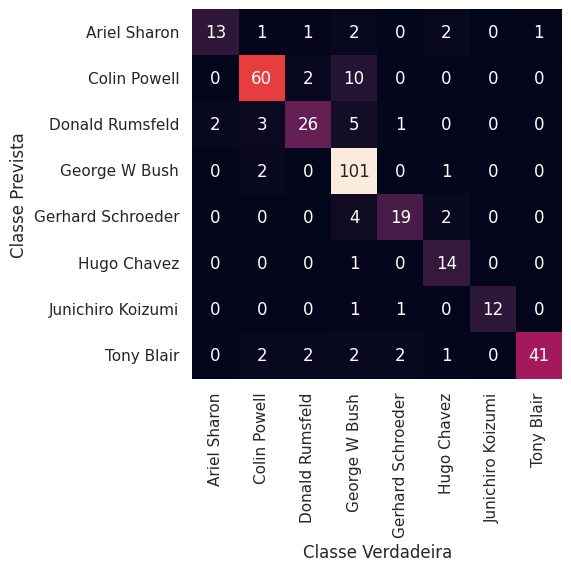

In [16]:
from sklearn.metrics import confusion_matrix
mat = confusion_matrix(ytest, yfit)
sns.heatmap(mat.T, square=True, annot=True, fmt='d', cbar=False,
            xticklabels=faces.target_names,
            yticklabels=faces.target_names)
plt.xlabel('Classe Verdadeira')
plt.ylabel('Classe Prevista');